<div style="display:flex; background-color:RGB(255,114,0);">
<h1 style="margin:auto; padding:30px; color:#fff;">P13 — SEGMENTATION DU CATALOGUE BOTTLENECK PAR CLUSTERING</h1>
</div>

# Objectif de ce notebook

Ce notebook **prolonge le projet 6** (analyse du stock et des ventes du site BottleNeck).

Le P6 décrivait le catalogue **variable par variable** : analyse univariée du prix, du chiffre
d'affaires, des quantités vendues, du stock et de la marge. C'est une analyse de **constat** :
elle photographie chaque dimension isolément, mais elle ne dit pas **comment regrouper les produits**
pour décider (assortiment, pricing, gestion de stock).

L'objectif du P13 est de passer d'une lecture univariée à une **segmentation multivariée et
automatisée** par **machine learning non supervisé (clustering)** : on croise les dimensions pour
faire émerger, de façon *data-driven*, des **familles de produits** actionnables. Ce n'est plus
l'analyste qui fixe les segments a priori, c'est l'algorithme qui les révèle — l'analyste se
chargeant de les **interpréter, nommer et traduire en recommandations**.

La démarche est **critique et comparée** (consignes P13) : on teste **deux jeux de variables**,
**deux algorithmes**, on justifie le nombre de segments par des métriques objectives, et on
documente chaque décision — y compris celles qui conduisent à écarter une piste.

> **Pourquoi un notebook séparé du P6 ?** Le P6 reste le notebook de *nettoyage et d'exploration*.
> Le P13 repart directement de l'**export consolidé** produit à la fin du P6
> (`df_merge_bottleneck.xlsx`). On évite de rejouer toute la chaîne de préparation, on gagne en
> reproductibilité, et on garde deux livrables lisibles.

<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Étape 1 — Chargement et audit de l'export P6</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42          # reproductibilité : graine fixée pour tout le notebook

# Export consolidé et nettoyé produit à l'issue du P6
df = pd.read_excel("df_merge_bottleneck.xlsx")
print(f"Export P6 chargé : {df.shape[0]} produits, {df.shape[1]} colonnes")
df.head()

Export P6 chargé : 825 produits, 12 colonnes


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,post_title,prix_ht,taux_marge
0,3847,1,24.2,16,instock,12.88,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,20.166667,0.565735
1,3849,1,34.3,10,instock,17.54,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,28.583333,0.629609
2,3850,1,20.8,0,outofstock,10.64,15300,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,17.333333,0.629073
3,4032,1,14.1,26,instock,6.92,19814,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,11.750000,0.697977
4,4039,1,46.0,3,instock,23.77,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,38.333333,0.612677


### Audit de complétude et de types

Avant toute modélisation, on vérifie ce que contient réellement l'export : types, complétude,
cardinalité. C'est le garde-fou minimal contre les colonnes piégées (types mixtes, manquants massifs).

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "n_uniques": df.nunique(),
    "taux_manquant_%": (df.isna().mean() * 100).round(1),
})
audit

,dtype,non_null,n_uniques,taux_manquant_%
product_id,int64,825,825,0.0
onsale_web,int64,825,2,0.0
price,float64,825,381,0.0
stock_quantity,int64,825,82,0.0
stock_status,str,825,2,0.0
purchase_price,float64,825,660,0.0
id_web,object,734,734,11.0
total_sales,float64,714,24,13.5
product_type,str,713,6,13.6
post_title,str,714,711,13.5


On note d'emblée trois colonnes à surveiller : `total_sales`, `product_type` et `post_title`
présentent des manquants — ce sont les produits **absents du site web** (l'export ERP couvre plus de
références que le site marchand). C'est un signal métier, pas une erreur : ces produits n'ont pas de
donnée de vente et sortiront naturellement du périmètre de la segmentation.

> **Note sur `post_date`** — contrairement à d'autres exports du même projet, cet export **ne contient
> pas la date de mise en ligne des fiches**. La dimension « ancienneté produit » n'est donc pas
> exploitable ici : la segmentation s'appuiera sur le **positionnement prix**, le **volume de ventes**
> et la **rotation de stock**, sans axe temporel.

<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Étape 2 — Cadrage data : isoler les régimes particuliers avant le ML</h2>
</div>

**Hypothèse de départ** : tous les produits ne relèvent pas du même *régime*. Un produit jamais
vendu, ou absent du site, n'est pas « un produit qui vend peu » — c'est un **état qualitatif distinct**.
Demander à un algorithme de distance de deviner ces états reviendrait à polluer la géométrie des
clusters avec des points qui n'ont rien à y faire.

**Décision** : on isole ces cas par **règle métier explicite**, *avant* le clustering.

In [3]:
print("total_sales manquant (produits hors site web) :", int(df['total_sales'].isna().sum()))
print("total_sales == 0  (invendus)                    :", int((df['total_sales'] == 0).sum()))
print("total_sales  > 0  (produits vendus)             :", int((df['total_sales'] > 0).sum()))
print("prix <= 0                                       :", int((df['price'] <= 0).sum()))
print("taux_marge < 0 (marge négative)                 :", int((df['taux_marge'] < 0).sum()))

total_sales manquant (produits hors site web) : 111
total_sales == 0  (invendus)                    : 25
total_sales  > 0  (produits vendus)             : 689
prix <= 0                                       : 0
taux_marge < 0 (marge négative)                 : 4


On relève **4 marges négatives** — anomalie de saisie déjà repérée en P6 (prix d'achat > prix de
vente). Vérifions où elles tombent : sont-elles dans le cœur de catalogue, ou déjà captées par les
règles ci-dessus ?

In [4]:
neg = df[df['taux_marge'] < 0].copy()
neg['regime'] = np.select(
    [neg['total_sales'].isna(), neg['total_sales'] == 0],
    ["hors web", "invendu"], default="vendu")
neg[['product_id', 'price', 'purchase_price', 'total_sales', 'taux_marge', 'regime']]

,product_id,price,purchase_price,total_sales,taux_marge,regime
210,4355,12.65,77.48,0.0,-0.863943,invendu
391,4864,8.30,9.99,NaN,-0.307641,hors web
724,6324,92.00,99.00,NaN,-0.225589,hors web
817,7196,31.00,31.20,NaN,-0.172009,hors web


**Décision documentée** : les 4 marges négatives sont **toutes déjà isolées** (1 invendu +
3 hors-web). Aucune n'est dans le cœur de catalogue actif — inutile donc de créer une règle
supplémentaire. On les signale pour correction dans l'ERP (chantier P6), mais elles ne perturbent pas
la modélisation.

On construit maintenant les trois sous-ensembles et on **contrôle que le compte est bon** (825 reconstitué).

In [5]:
mask_horsweb  = df['total_sales'].isna()
mask_invendus = df['total_sales'].fillna(-1) == 0
df_core = df[df['total_sales'] > 0].copy()          # cœur de catalogue = base du clustering

n_hw, n_inv, n_core = int(mask_horsweb.sum()), int(mask_invendus.sum()), len(df_core)
print(f"Hors site web (écartés)         : {n_hw:>3}")
print(f"Invendus (isolés par règle)     : {n_inv:>3}")
print(f"Cœur de catalogue (clustering)  : {n_core:>3}")
print(f"Contrôle : {n_hw} + {n_inv} + {n_core} = {n_hw + n_inv + n_core}  (attendu : {len(df)})")

Hors site web (écartés)         : 111
Invendus (isolés par règle)     :  25
Cœur de catalogue (clustering)  : 689
Contrôle : 111 + 25 + 689 = 825  (attendu : 825)


<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Étape 3 — Feature engineering et pré-traitement</h2>
</div>

### Construction des variables métier

Deux variables ne sont pas dans l'export mais se déduisent des colonnes existantes :

| Variable créée | Formule | Dimension métier |
|---|---|---|
| `ca` | `price × total_sales` | Chiffre d'affaires du produit sur le mois |
| `stock_mois` | `stock_quantity / total_sales` | Rotation : nombre de mois pour écouler le stock (ventes d'octobre) |

`stock_mois` est notre **proxy de rotation** : élevé = stock qui dort, faible = produit qui tourne vite.

In [6]:
df_core['ca']         = df_core['price'] * df_core['total_sales']
df_core['stock_mois']  = df_core['stock_quantity'] / df_core['total_sales']
df_core[['price', 'total_sales', 'stock_quantity', 'stock_mois', 'ca', 'taux_marge']].describe().round(2)

,price,total_sales,stock_quantity,stock_mois,ca,taux_marge
count,689.00,689.00,689.00,689.00,689.00,689.00
mean,32.28,8.35,23.93,2.98,208.53,0.61
std,27.81,3.94,21.55,3.47,151.58,0.08
min,5.20,1.00,0.00,0.00,13.60,0.29
25%,14.00,5.00,10.00,1.75,125.10,0.57
50%,23.40,8.00,21.00,2.40,173.10,0.61
75%,42.00,11.00,31.00,3.09,246.00,0.66
max,225.00,36.00,145.00,31.25,2475.00,0.91


### Choix des variables : anti-fuite de données et variable non discriminante

Deux exclusions **explicites** des variables de clustering :

- **`ca` exclu (data leakage)** : `ca = total_sales × price` est colinéaire aux entrées, c'est un
  simple changement d'échelle. L'inclure ferait « fuiter » l'information des axes prix et ventes et
  gonflerait artificiellement la séparation. `ca` est **conservé en lecture seule** pour chiffrer le
  poids des segments a posteriori.
- **`taux_marge` écarté des axes** : vérifions sa dispersion.

In [7]:
q25, q50, q75 = df_core['taux_marge'].quantile([.25, .50, .75])
print(f"Taux de marge — 75 % des produits entre {q25:.1%} et {q75:.1%} (médiane {q50:.1%})")
print("→ variable quasi-plate : peu discriminante. Elle n'aiderait pas à séparer les groupes")
print("  et n'ajouterait que du bruit. Conservée EN LECTURE SEULE (hors clustering).")

Taux de marge — 75 % des produits entre 56.6% et 66.3% (médiane 61.3%)
→ variable quasi-plate : peu discriminante. Elle n'aiderait pas à séparer les groupes
  et n'ajouterait que du bruit. Conservée EN LECTURE SEULE (hors clustering).


### Transformation des distributions (justifiée par leur forme)

KMeans raisonne en **distances euclidiennes** : il est sensible (a) à l'**asymétrie** des
distributions — une longue traîne de valeurs élevées écrase les distances — et (b) à l'**échelle** —
une variable en centaines domine une variable en unités. On visualise donc les distributions avant
de décider des transformations.

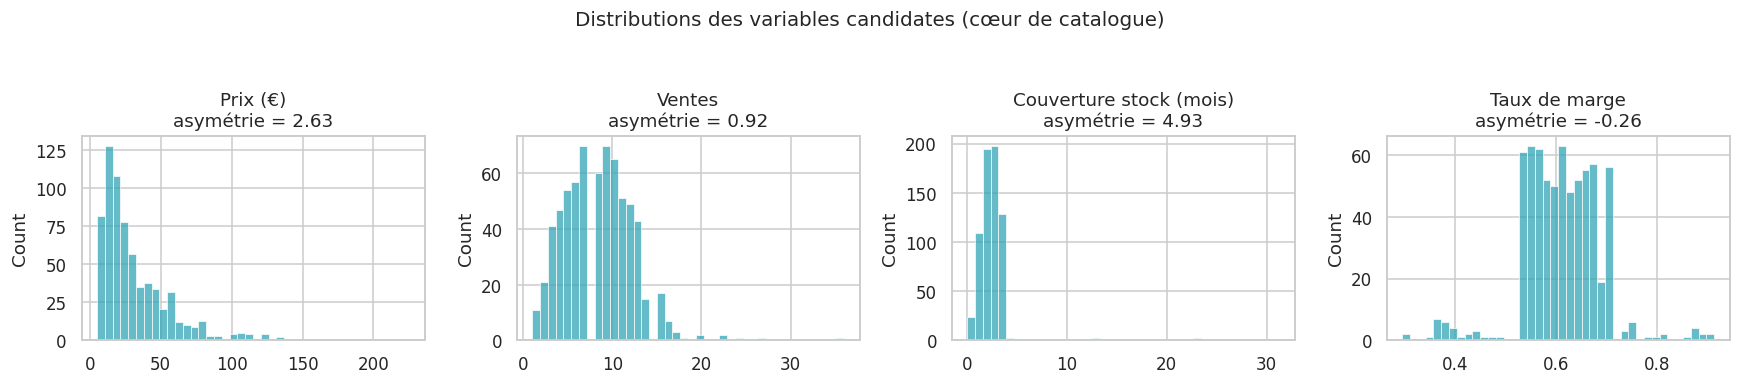

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))
cols = [('price', 'Prix (€)'), ('total_sales', 'Ventes'),
        ('stock_mois', 'Couverture stock (mois)'), ('taux_marge', 'Taux de marge')]
for ax, (col, title) in zip(axes, cols):
    sns.histplot(df_core[col], bins=40, ax=ax, color="#33A5B6")
    ax.set_title(f"{title}\nasymétrie = {df_core[col].skew():.2f}")
    ax.set_xlabel("")
plt.suptitle("Distributions des variables candidates (cœur de catalogue)", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

**Lecture** : `price`, `total_sales` et `stock_mois` sont **fortement asymétriques à droite**
(longue traîne) → on applique `log1p` pour les rapprocher d'une forme symétrique. La marge est déjà
quasi-symétrique et resserrée (et de toute façon écartée du clustering).

| Opération | Appliquée à | Pourquoi |
|---|---|---|
| `log1p` | `price`, `total_sales`, `stock_mois` | Corriger l'asymétrie droite (traîne qui écraserait les distances) |
| `StandardScaler` | tous les axes retenus | Mettre à la même échelle (centré-réduit) : sinon une variable domine |

In [9]:
# log1p sur les variables à forte asymétrie droite
df_core['price_log'] = np.log1p(df_core['price'])
df_core['sales_log'] = np.log1p(df_core['total_sales'])
df_core['stock_log'] = np.log1p(df_core['stock_mois'])

def build_X(frame, cols):
    """Standardise un jeu de variables (déjà transformées) et vérifie l'absence de NaN/inf."""
    X = StandardScaler().fit_transform(frame[cols])
    assert not np.isnan(X).any() and not np.isinf(X).any(), "NaN/inf détecté dans X !"
    return X

X_A = build_X(df_core, ['price_log', 'sales_log'])                 # Variante A : 2 axes
X_B = build_X(df_core, ['price_log', 'sales_log', 'stock_log'])    # Variante B : 3 axes
print("Garde-fou OK — X_A :", X_A.shape, "| X_B :", X_B.shape, "| aucun NaN/inf")

Garde-fou OK — X_A : (689, 2) | X_B : (689, 3) | aucun NaN/inf


<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Étape 4 — Modélisation comparée : deux variantes, deux algorithmes</h2>
</div>

C'est le cœur de la démarche critique. On compare **deux jeux de variables** avec les **mêmes
algorithmes** et les **mêmes métriques**, puis on arbitre :

- **Variante A — 2 axes** : `prix`, `ventes`. La segmentation « évidente », accessible à l'œil.
- **Variante B — 3 axes** : on **ajoute la rotation de stock** (`stock_mois`).

Pour chaque variante, on balaye `k` de 2 à 7 et on croise :
- l'**inertie intra-classe** (méthode du **coude**),
- le **score de silhouette** pour **KMeans** *et* pour le **clustering hiérarchique** (Ward),
- l'**accord entre les deux algorithmes** (ARI) — témoin de robustesse.

In [10]:
def scan_k(X, kmax=7):
    rows = []
    for k in range(2, kmax + 1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
        ag = AgglomerativeClustering(n_clusters=k).fit(X)     # linkage='ward' par défaut
        rows.append({
            'k': k,
            'inertie': round(km.inertia_, 1),
            'silh_kmeans': round(silhouette_score(X, km.labels_), 3),
            'silh_hierarchique': round(silhouette_score(X, ag.labels_), 3),
            'accord_ARI': round(adjusted_rand_score(km.labels_, ag.labels_), 3),
        })
    return pd.DataFrame(rows).set_index('k')

scan_A = scan_k(X_A)
scan_B = scan_k(X_B)
print("Variante A — 2 axes (prix, ventes)")
scan_A

Variante A — 2 axes (prix, ventes)


,inertie,silh_kmeans,silh_hierarchique,accord_ARI
k,,,,
2,558.6,0.509,0.497,0.881
3,379.3,0.408,0.371,0.465
4,302.0,0.366,0.308,0.524
5,258.4,0.369,0.297,0.428
6,222.5,0.340,0.301,0.356
7,192.7,0.335,0.326,0.447


In [11]:
print("Variante B — 3 axes (prix, ventes, rotation de stock)")
scan_B

Variante B — 3 axes (prix, ventes, rotation de stock)


,inertie,silh_kmeans,silh_hierarchique,accord_ARI
k,,,,
2,1231.8,0.437,0.429,0.827
3,796.3,0.481,0.471,0.788
4,643.4,0.340,0.403,0.404
5,527.8,0.333,0.291,0.639
6,450.2,0.348,0.300,0.607
7,404.1,0.358,0.309,0.636


**Choix du nombre de clusters.** Pour la variante B, la silhouette KMeans **culmine à k=3
(0,481)** et l'inertie marque un **coude net** au même endroit (chute de 1232 → 796 puis
ralentissement). Les deux critères **convergent sur k=3**. KMeans domine le hiérarchique sur la
silhouette à toutes les valeurs de k, et l'**accord ARI de 0,79** à k=3 confirme que les deux
algorithmes voient la **même structure** → **KMeans retenu**, hiérarchique conservé comme témoin.

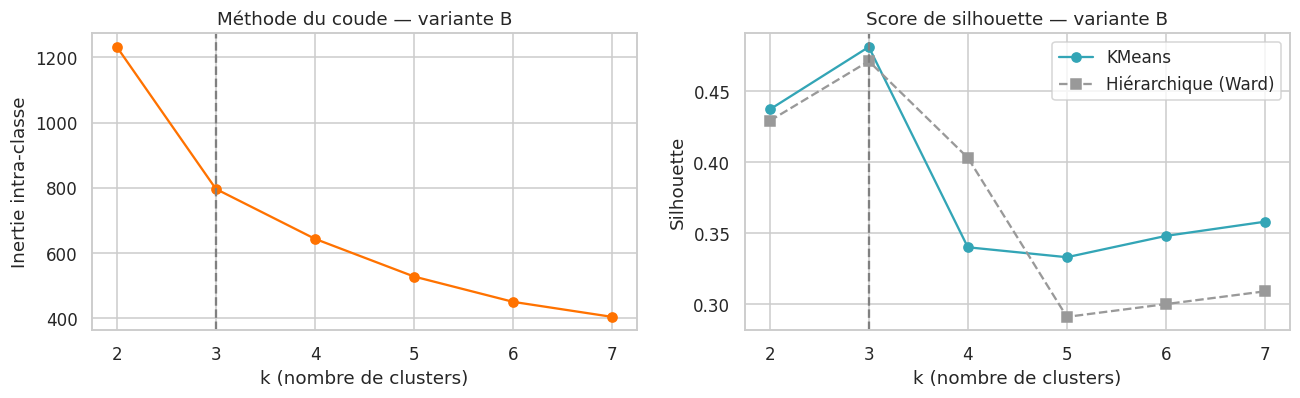

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax1.plot(scan_B.index, scan_B['inertie'], 'o-', color="#FF7200")
ax1.axvline(3, ls='--', color='grey')
ax1.set(title="Méthode du coude — variante B", xlabel="k (nombre de clusters)", ylabel="Inertie intra-classe")
ax2.plot(scan_B.index, scan_B['silh_kmeans'], 'o-', label="KMeans", color="#33A5B6")
ax2.plot(scan_B.index, scan_B['silh_hierarchique'], 's--', label="Hiérarchique (Ward)", color="#999")
ax2.axvline(3, ls='--', color='grey')
ax2.set(title="Score de silhouette — variante B", xlabel="k (nombre de clusters)", ylabel="Silhouette")
ax2.legend()
plt.tight_layout()
plt.show()

### Ce que voit la variante A (2 axes) — profils à k=3

On regarde d'abord les segments de la variante « évidente », pour objectiver ce qu'elle **ne voit pas**.

In [13]:
def profils(frame, labels):
    return (frame.assign(cluster=labels)
            .groupby('cluster')
            .agg(nb_produits=('price', 'size'),
                 prix_median=('price', 'median'),
                 ventes_median=('total_sales', 'median'),
                 stock_mois_median=('stock_mois', 'median'),
                 marge_mediane=('taux_marge', 'median'),
                 ca_total=('ca', 'sum'))
            .round(2))

km_A = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X_A)
profils(df_core, km_A.labels_)

,nb_produits,prix_median,ventes_median,stock_mois_median,marge_mediane,ca_total
cluster,,,,,,
0,159,58.80,4.0,1.67,0.61,41626.5
1,276,12.80,12.0,2.77,0.61,43299.8
2,254,27.75,7.0,2.29,0.61,58753.8


**Constat** : la variante A sépare les produits **par palier de prix** (≈13 € / ≈28 € / ≈59 €),
avec des ventes décroissantes. Mais la **couverture de stock est homogène partout** (~1,7 à 2,8 mois) :
**aucun segment ne capte le stock qui dort**. Les produits à rotation très lente sont dilués dans les
paliers de prix, invisibles.

### Ce que révèle la variante B (3 axes) — profils à k=3

In [14]:
km_B = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X_B)
df_core['cluster'] = km_B.labels_
profils(df_core, km_B.labels_)

,nb_produits,prix_median,ventes_median,stock_mois_median,marge_mediane,ca_total
cluster,,,,,,
0,244,46.25,5.0,1.57,0.61,62094.25
1,413,15.90,10.0,2.75,0.61,69721.25
2,32,60.55,6.0,16.50,0.40,11864.60


In [15]:
ag_B = AgglomerativeClustering(n_clusters=3).fit(X_B)
print("Accord KMeans vs Hiérarchique à k=3 (ARI, 1 = partitions identiques) :",
      round(adjusted_rand_score(km_B.labels_, ag_B.labels_), 3))

Accord KMeans vs Hiérarchique à k=3 (ARI, 1 = partitions identiques) : 0.788


**Le 3ᵉ segment apparaît** : un groupe d'une trentaine de produits **chers** (~60 €), à ventes
modestes, mais surtout à **couverture de stock ≈ 16 mois** et **marge nettement plus basse (~40 %)**.
Ce segment était **invisible** dans la variante A — fondu dans les paliers de prix. C'est exactement
la valeur ajoutée du ML multivarié : révéler une structure qu'une lecture à deux axes ne montre pas.

<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Étape 5 — Arbitrage, validation et nommage des segments</h2>
</div>

### Arbitrage multi-critères entre les deux variantes

| Critère | Variante A (2 axes) | Variante B (3 axes) | Gagnant |
|---|---|---|---|
| **Netteté statistique** (silhouette k=3) | 0,408 | **0,481** | **B** |
| **Robustesse** (accord ARI KMeans/hiérarchique) | — | 0,79 | B |
| **Parcimonie** (nombre d'axes) | 2 axes | 3 axes | A |
| **Valeur métier** (segments actionnables) | 3 paliers de prix | **révèle le stock dormant** | **B** |

**Décision : variante B (3 axes, k=3).** Ici l'enrichissement **ne coûte rien** : la variante B est
*à la fois* plus nette statistiquement (0,481 > 0,408) *et* plus actionnable. Le seul avantage de A
(parcimonie) ne pèse pas face à un segment décisionnel entier qu'elle masquait.

> **Piste écartée et documentée** : une variante à 4 axes ajoutant `taux_marge` a été testée. Elle
> **dégrade** la silhouette (0,393) sans créer de segment neuf — cohérent avec le fait que la marge
> est quasi-plate. Confirmation *a posteriori* du choix de l'exclure des axes.

### Validation : le segment révélé est-il réel ou un artefact d'outliers ?

On nomme d'abord les segments par **règle sur leurs caractéristiques** (robuste à l'ordre non garanti
des labels KMeans), puis on inspecte la dispersion du segment « stock dormant ».

In [16]:
# Nommage robuste : on identifie chaque cluster par ses médianes, pas par son numéro
med = df_core.groupby('cluster').agg(stock=('stock_mois', 'median'), prix=('price', 'median'))
c_dormant = med['stock'].idxmax()                       # rotation la plus lente → stock dormant
reste     = med.drop(index=c_dormant)
c_moteur  = reste['prix'].idxmin()                      # prix le plus bas  → moteur de CA (volume)
c_premium = reste['prix'].idxmax()                      # prix le plus haut → premium

noms = {c_moteur: "Moteur de CA", c_premium: "Premium", c_dormant: "Stock dormant"}
df_core['segment'] = df_core['cluster'].map(noms)
df_core['segment'].value_counts()

,count
segment,
Moteur de CA,413
Premium,244
Stock dormant,32


In [17]:
# Le 4ᵉ segment est-il homogène (vrai groupe) ou tiré par quelques valeurs extrêmes ?
df_core.loc[df_core['segment'] == "Stock dormant", 'stock_mois'].describe().round(2)

,stock_mois
count,32.00
mean,16.93
std,6.42
min,6.00
25%,12.12
50%,16.50
75%,21.20
max,31.25


**Validation OK** : le segment *Stock dormant* a un **minimum de 6 mois** de couverture et un
**premier quartile à ~12 mois** — la dispersion est resserrée et haute. Ce n'est pas un artefact tiré
par 2-3 outliers : c'est un **vrai groupe** de produits chers qui dorment. Il peut être traité en
priorité par le métier.

<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Étape 6 — Restitution : trois segments métier exploitables</h2>
</div>

In [18]:
recap = (df_core.groupby('segment')
         .agg(nb_produits=('price', 'size'),
              prix_median=('price', 'median'),
              ventes_median=('total_sales', 'median'),
              stock_mois_median=('stock_mois', 'median'),
              marge_mediane=('taux_marge', 'median'),
              ca_total=('ca', 'sum'))
         .round(2)
         .sort_values('ca_total', ascending=False))
recap['ca_%'] = (recap['ca_total'] / recap['ca_total'].sum() * 100).round(1)
recap

,nb_produits,prix_median,ventes_median,stock_mois_median,marge_mediane,ca_total,ca_%
segment,,,,,,,
Moteur de CA,413,15.90,10.0,2.75,0.61,69721.25,48.5
Premium,244,46.25,5.0,1.57,0.61,62094.25,43.2
Stock dormant,32,60.55,6.0,16.50,0.40,11864.60,8.3


### Visualisation finale : le segment révélé

Une seule visualisation, choisie pour **montrer ce que le ML apporte** : en croisant **couverture de
stock** (axe x) et **marge** (axe y), le *Stock dormant* se détache nettement en bas à droite — cher,
peu rentable, invendable rapidement.

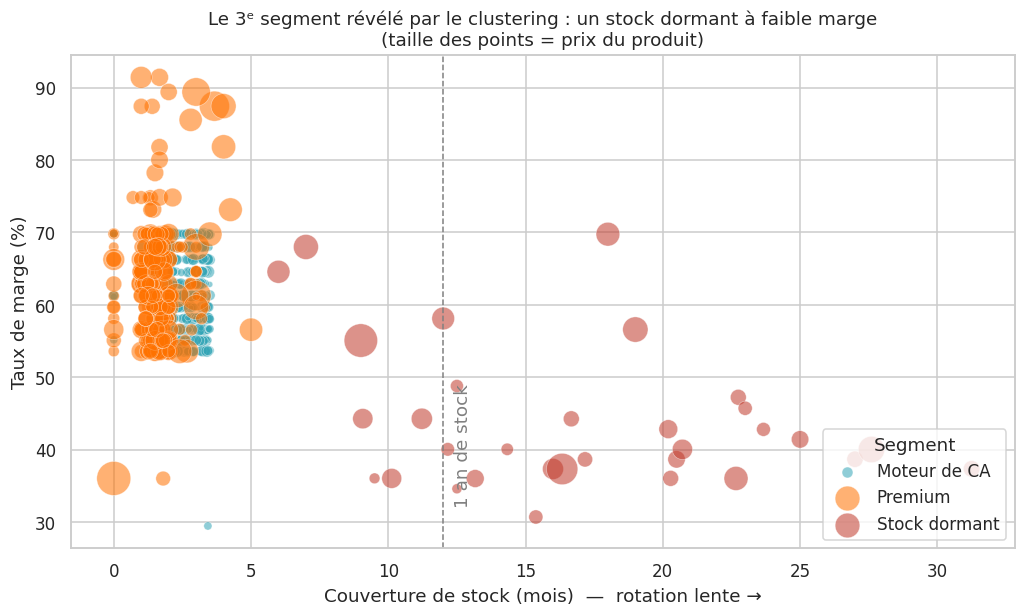

In [19]:
palette = {"Moteur de CA": "#33A5B6", "Premium": "#FF7200", "Stock dormant": "#C0392B"}
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for seg, sub in df_core.groupby('segment'):
    ax.scatter(sub['stock_mois'], sub['taux_marge'] * 100,
               s=sub['price'] * 2.2, alpha=0.55, label=seg,
               color=palette[seg], edgecolor="white", linewidth=0.4)
ax.axvline(12, ls='--', color='grey', lw=1)
ax.text(12.4, 32, "1 an de stock", color='grey', rotation=90, va='bottom')
ax.set(xlabel="Couverture de stock (mois)  —  rotation lente →",
       ylabel="Taux de marge (%)",
       title="Le 3ᵉ segment révélé par le clustering : un stock dormant à faible marge\n"
             "(taille des points = prix du produit)")
ax.legend(title="Segment", loc="lower right")
plt.tight_layout()
plt.show()

### Export du catalogue segmenté (CSV)

On met à disposition du métier un **fichier CSV** (format directement exploitable dans Excel) reliant
chaque produit à son segment.

In [20]:
export = df_core[['product_id', 'post_title', 'product_type', 'price', 'total_sales',
                  'stock_quantity', 'stock_mois', 'ca', 'taux_marge', 'segment']].copy()
export.to_csv("bottleneck_segments_p13.csv", index=False, encoding="utf-8-sig")
print(f"Catalogue segmenté exporté : {len(export)} produits → bottleneck_segments_p13.csv")
export.head()

Catalogue segmenté exporté : 689 produits → bottleneck_segments_p13.csv


,product_id,post_title,product_type,price,total_sales,stock_quantity,stock_mois,ca,taux_marge,segment
0,3847,Pierre Jean Villa Saint-Joseph Préface 2018,Vin,24.2,6.0,16,2.666667,145.2,0.565735,Moteur de CA
1,3849,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Vin,34.3,9.0,10,1.111111,308.7,0.629609,Premium
3,4032,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,Vin,14.1,12.0,26,2.166667,169.2,0.697977,Moteur de CA
4,4039,Pierre Jean Villa Côte Rôtie Carmina 2017,Vin,46.0,3.0,3,1.000000,138.0,0.612677,Premium
5,4040,Pierre Jean Villa Saint-Joseph Saut De l'Ange 2018,Vin,34.3,7.0,12,1.714286,240.1,0.566210,Premium


<div style="background-color:RGB(51,165,182);">
<h2 style="margin:auto; padding:20px; color:#fff;">Conclusion — synthèse, recommandations et limites</h2>
</div>

### Trois segments + un groupe isolé

| Segment | Volume | Profil (médianes) | Lecture métier |
|---|---|---|---|
| **Moteur de CA** | 413 | prix 16 € · ventes 10 · stock 2,8 mois · marge 61 % | Le fond de commerce : entrée/milieu de gamme qui tourne, **plus gros CA total** par effet volume. |
| **Premium** | 244 | prix 46 € · ventes 5 · stock 1,6 mois · marge 61 % | Haut de gamme à **rotation rapide** : peu d'unités mais fort panier, stock sain. |
| **Stock dormant** | 32 | prix 61 € · **stock 16,5 mois** · marge 40 % | **Capital immobilisé** : produits chers, peu rentables, > 1 an d'écoulement. |
| *Invendus (isolés)* | 25 | `total_sales = 0` | Stock dormant absolu, sortis par règle avant le ML — décision à trancher. |

### Recommandations par segment

- **Moteur de CA →** priorité absolue à la **disponibilité** : une rupture = perte directe de chiffre.
  C'est le socle à ne jamais laisser tomber en stock.
- **Premium →** ne pas juger sur le volume : rotation lente ≠ problème tant que le stock reste sain.
  Piloter par le **niveau de stock** plutôt que pousser les ventes.
- **Stock dormant →** **action prioritaire** : déstockage ciblé, promo de liquidation ou arrêt de
  réapprovisionnement. C'est ici que dort du cash sans contrepartie de marge.
- **Invendus →** décision binaire à prendre produit par produit (relancer / arrêter).

### Apport du ML vs analyse manuelle

Une segmentation intuitive sur le seul couple **prix / ventes** (variante A) retrouve les segments
évidents mais **masque le stock dormant**. C'est l'ajout de la **rotation de stock** qui fait émerger
ces 32 produits chers à faible marge — invisibles sur le plan prix/ventes car dilués dans le Premium.
Le ML apporte ici une **frontière reproductible, multivariée et scalable**, là où l'analyse manuelle
reste subjective et limitée à deux ou trois axes simultanés.

### Limites et biais

- **Silhouette modeste (~0,48)** : le catalogue est plutôt un **continuum** qu'un ensemble de paquets
  nettement isolés. Segments **statistiquement modestes mais métier-pertinents** — assumé.
- **Faible volume (689 produits)** : segmentation **exploratoire** (POC), non déployable en l'état,
  à reconsolider sur un historique plus large.
- **Snapshot (octobre)** : pas de dimension temporelle des ventes → pas de notion de tendance /
  saisonnalité, et **pas d'axe ancienneté** (absent de l'export).
- **Choix de k et des variables** : part de subjectivité, encadrée par les métriques (silhouette,
  coude, ARI) et l'arbitrage documenté.

### Reproductibilité

- `random_state = 42` sur KMeans, `n_init = 10`.
- Aucune dépendance à la date d'exécution (pas d'ancienneté calculée sur `today()`).
- Source de travail = **export Excel du P6**, notebook séparé et rejouable de bout en bout.
- Garde-fou `assert` contre les `NaN`/`inf` avant chaque clustering.

### Usage de l'IA dans la démarche

Un assistant IA a été mobilisé comme **outil de travail critique** : brainstorming des axes de
segmentation, aide au code scikit-learn, relecture méthodologique (détection du *data leakage* sur
`ca`, choix des transformations selon la forme des distributions). Chaque suggestion a été **validée
ou écartée** explicitement — l'abandon d'une piste ancienneté (donnée absente), le rejet de la
variante à 4 axes avec marge (dégradation mesurée), l'exclusion de `ca`. Les décisions finales
(variables retenues, choix de k, arbitrage) relèvent d'un **jugement métier et statistique assumé**,
l'IA servant à accélérer et fiabiliser, non à décider.